[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/AI-og-helse/blob/main/uke06-klinisk-praksis/01_risikomodell_logistisk_regresjon_kalibrering_shap.ipynb)


# 🏥 Syntetisk risikomodell i klinisk praksis: logistisk regresjon, kalibrering og SHAP

Denne notebooken tar utgangspunkt i en enkel klinisk situasjon: Vi ønsker å anslå risiko for at en pasient tilhører en gruppe som trenger tettere oppfølging eller videre vurdering. Dataene er syntetiske, men poenget er klinisk: Hvordan går vi fra en modell som gir sannsynligheter til noe som kan brukes som beslutningsstøtte?

Logistisk regresjon er valgt her fordi den er et godt startpunkt i klinisk praksis. Den er relativt lett å forstå, lett å kalibrere og egner seg godt når målet ikke bare er høy prediksjonsytelse, men også transparens og etterprøvbarhet.

## Læringsmål
- Trene en enkel og klinisk forståelig risikomodell
- Vurdere både diskriminering (AUROC) og kalibrering (Brier/kurver)
- Tolke hva modellresultater betyr i en klinisk beslutningssituasjon
- Bruke SHAP til å utforske hvorfor modellen anslår høy eller lav risiko


### 🔧 Miljøoppsett – fungerer både lokalt og i Google Colab


In [1]:
import sys, subprocess, os
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    print("🚀 Kjører i Google Colab")
    # SHAP kan mangle i base-Colab
    try:
        import shap  # noqa: F401
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])  # type: ignore
    if not os.path.exists('AI-og-helse'):
        print("📥 Laster ned kursmateriell...")
        subprocess.check_call(["git", "clone", "https://github.com/arvidl/AI-og-helse.git"])  # type: ignore
    if os.path.exists('AI-og-helse'):
        os.chdir('AI-og-helse')
        print(f"📁 Byttet til mappe: {os.getcwd()}")
else:
    print("💻 Kjører i lokalt miljø")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve
import shap

rng = np.random.default_rng(42)
print("✅ Miljø klart")


💻 Kjører i lokalt miljø
✅ Miljø klart


In [2]:
# Syntetiske data
X, y = make_classification(
    n_samples=3000,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    weights=[0.7, 0.3],
    class_sep=1.0,
    random_state=42,
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)


(2250, 20) (750, 20)


## Klinisk tolkning av modellresultatene

AUROC sier noe om hvor godt modellen skiller mellom grupper, men i klinisk praksis er det ofte minst like viktig om sannsynlighetene er rimelige. En modell kan rangere pasienter godt og likevel overvurdere eller undervurdere faktisk risiko.

Derfor er kalibrering viktig: Hvis modellen anslår 30 % risiko, bør det i grove trekk bety at omtrent 30 av 100 lignende pasienter faktisk får utfallet. SHAP kan så brukes som et supplement for å undersøke hvilke variabler som trekker risikoanslaget opp eller ned for enkeltpasienter eller grupper, men slike forklaringer må alltid tolkes i lys av fagkunnskap og datagrunnlag.


AUROC: 0.838  |  Brier: 0.134


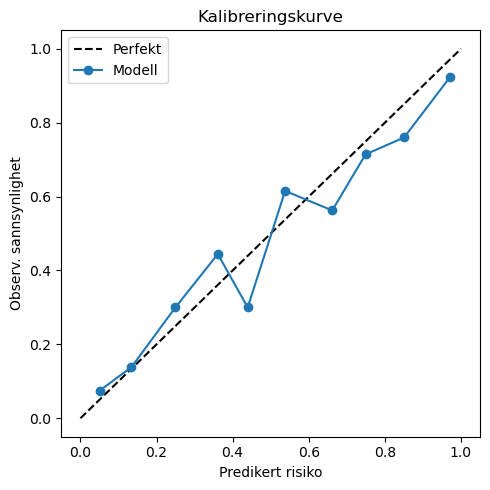

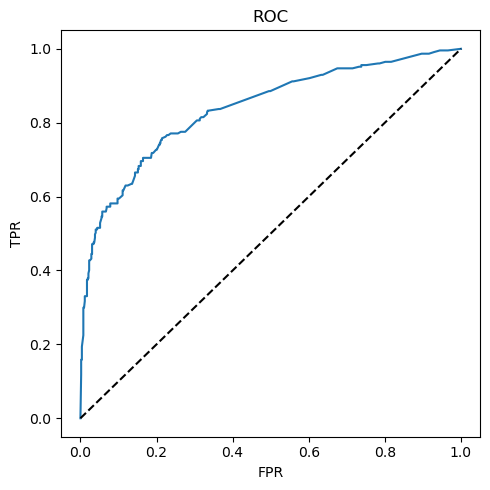

In [3]:
# Modell og kalibrering
base = LogisticRegression(max_iter=1000, solver='lbfgs')
base.fit(X_train, y_train)
cal = CalibratedClassifierCV(estimator=base, method="isotonic", cv=5)
cal.fit(X_train, y_train)

proba_test = cal.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba_test)
brier = brier_score_loss(y_test, proba_test)
print(f"AUROC: {auc:.3f}  |  Brier: {brier:.3f}")

# Kalibreringskurve
prob_true, prob_pred = calibration_curve(y_test, proba_test, n_bins=10, strategy='uniform')
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
plt.plot([0,1],[0,1], 'k--', label='Perfekt')
plt.plot(prob_pred, prob_true, marker='o', label='Modell')
plt.xlabel('Predikert risiko')
plt.ylabel('Observ. sannsynlighet')
plt.title('Kalibreringskurve')
plt.legend(); plt.tight_layout(); plt.show()

# ROC-kurve
fpr, tpr, thr = roc_curve(y_test, proba_test)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC'); plt.tight_layout(); plt.show()


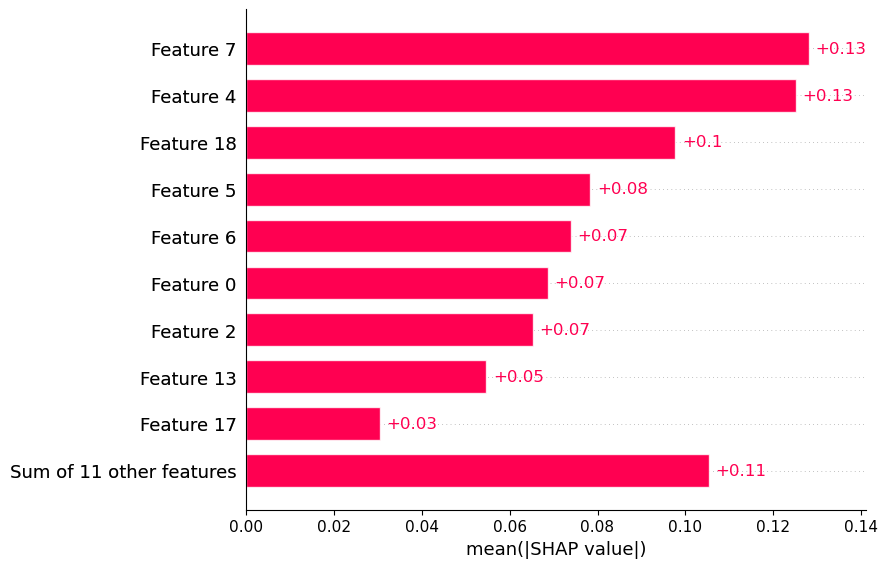

In [4]:
# SHAP-forklaringer
explainer = shap.Explainer(cal.predict_proba, X_train)
shap_values = explainer(X_test[:200])

# For binar klassifikasjon returnerer SHAP ofte forklaringer for begge klassene.
# Vi visualiserer klasse 1 (positiv klasse) når den er tilgjengelig.
if shap_values.values.ndim == 3:
    shap_values_pos = shap_values[:, :, 1]
else:
    shap_values_pos = shap_values

# Global oversikt (bar)
shap.plots.bar(shap_values_pos, max_display=10)

# Lokal forklaring (force plot) – vis første
shap.plots.force(shap_values_pos[0])


### Refleksjon
- I hvilke kliniske situasjoner er god kalibrering viktigere enn høy AUROC?
- Hva ville konsekvensen være dersom modellen systematisk overvurderer eller undervurderer risiko?
- Hvordan kan SHAP være nyttig for en kliniker, og når kan slike forklaringer bli misvisende?
- Hvilken terskel ville du valgt dersom modellen skulle brukes til videre utredning eller tettere oppfølging, og hvorfor?
- Hva måtte vært på plass før en slik modell kunne brukes som reell beslutningsstøtte i klinisk praksis?
